In [19]:
# Colab-specific setup: mount Drive or upload file
# Option 1: Mount Google Drive (if dataset is stored there)
# from google.colab import drive
# drive.mount('/content/drive')
# data_path = '/content/drive/MyDrive/Customer Churn new.csv'

# Option 2: Upload directly (uncomment if needed):
# from google.colab import files
# uploaded = files.upload()
# data_path = 'Customer Churn new.csv'

# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For resampling and modeling
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score

# Imbalanced-learn for SMOTE
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Set random seed for reproducibility
np.random.seed(42)

# Load the dataset
df = pd.read_csv("Customer Churn new.csv")
#df = pd.read_csv(data_path)
#print(f"Dataset loaded. Shape: {df.shape}")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,747,15787619,Hsieh,844,France,Male,18,2,160980.03,145936.28,0
1,1620,15770309,McDonald,656,France,Male,18,10,151762.74,127014.32,0
2,1679,15569178,Kharlamov,570,France,Female,18,4,82767.42,71811.90,0
3,2022,15795519,Vasiliev,716,Germany,Female,18,3,128743.80,197322.13,0
4,2137,15621893,Bellucci,727,France,Male,18,4,133550.67,46941.41,0


In [17]:
# ---------------------------------------------------------
# 3. TRAINING WITH TWO DISTINCT ALGORITHMS (MSc Level)
# ---------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

# Define Features and Target
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling (Required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ALGORITHM 1: Logistic Regression (with Class Balancing)
lr_model = LogisticRegression(random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# ALGORITHM 2: Random Forest (Non-linear Machine Learning Algorithm)
# This satisfies the requirement for two distinct models for a group of 2
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train) # RF doesn't strictly require scaling, but we use raw data here

print("Training Complete: Logistic Regression and Random Forest models are ready.")

Training Complete: Logistic Regression and Random Forest models are ready.



--- Logistic Regression Results ---
Accuracy: 0.7090
F1-Score (Better metric for Churn): 0.4840
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.38      0.67      0.48       407

    accuracy                           0.71      2000
   macro avg       0.64      0.69      0.64      2000
weighted avg       0.79      0.71      0.73      2000


--- Random Forest Results ---
Accuracy: 0.8150
F1-Score (Better metric for Churn): 0.3813
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      1593
           1       0.60      0.28      0.38       407

    accuracy                           0.81      2000
   macro avg       0.72      0.62      0.64      2000
weighted avg       0.79      0.81      0.79      2000



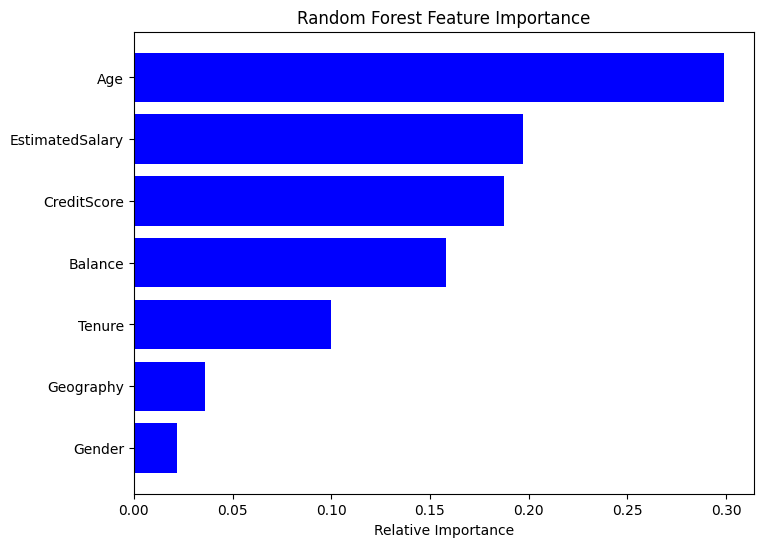

In [18]:
# ---------------------------------------------------------
# 4. RESULTS COMPARISON (For your Report Appendix)
# ---------------------------------------------------------
from sklearn.metrics import accuracy_score, f1_score

models = {"Logistic Regression": (lr_model, X_test_scaled),
          "Random Forest": (rf_model, X_test)}

for name, (model, data) in models.items():
    preds = model.predict(data)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score (Better metric for Churn): {f1:.4f}")
    print(classification_report(y_test, preds))

# Plot Feature Importance for Random Forest (MSc students look for 'why' the model works)
importances = rf_model.feature_importances_
indices = np.argsort(importances)
plt.figure(figsize=(8, 6))
plt.title('Random Forest Feature Importance')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()